In [1]:
# Import core libraries


import pandas as pd
import matplotlib.pyplot as plt

# import project modules
from fitness_entry import FitnessEntry
from data_loader import load_fitness_data
from user_profile import UserProfile
from analysis import generate_report
from visualization import (
    plot_steps_trend,
    plot_heart_rate_trend,
    plot_steps_histogram
)
from utils import (
    convert_steps_to_miles,
    filter_high_heart_rate,
    get_step_counts,
    recursive_sum_steps
)

In [2]:
file_path = "tracker_fitness_data.csv"

# Load all fitness entries from teh CSV
entries = load_fitness_data(file_path)
print(f"Loaded {len(entries)} entries.")


Loaded 1000000 entries.


In [3]:
# Create three user profiles
names = ["Shaun", "Miguel", "Ayush"]
profiles = [UserProfile(name) for name in names]

# Assign entries 
i = 0
for e in entries:
    profiles[i % 3].add_entry(e)
    i = i + 1

# Print summary of each profile
for p in profiles:
    print(p)

UserProfile(name=Shaun, entries=333334)
UserProfile(name=Miguel, entries=333333)
UserProfile(name=Ayush, entries=333333)


In [4]:
for p in profiles:
    print(f"\n--- Fitness Report for {p.name} ---")
    generate_report(p)


--- Fitness Report for Shaun ---

===== FITNESS REPORT =====
Total Days: 333334

Averages:
  Heart Rate: 119.46 bpm
  Steps: 15017.24
  Calories: 2748.69
  Walking Time: 718.67 min

Peaks:
  Max Heart Rate: 179
  Max Steps: 29999
  Max Calories: 3999.99
  Max Walking Time: 1439.0 min

Variability (Standard Deviation):
  Heart Rate Std Dev: 34.66
  Steps Std Dev: 8660.52


--- Fitness Report for Miguel ---

===== FITNESS REPORT =====
Total Days: 333333

Averages:
  Heart Rate: 119.35 bpm
  Steps: 15005.00
  Calories: 2751.32
  Walking Time: 719.16 min

Peaks:
  Max Heart Rate: 179
  Max Steps: 29999
  Max Calories: 4000.0
  Max Walking Time: 1439.0 min

Variability (Standard Deviation):
  Heart Rate Std Dev: 34.62
  Steps Std Dev: 8658.69


--- Fitness Report for Ayush ---

===== FITNESS REPORT =====
Total Days: 333333

Averages:
  Heart Rate: 119.56 bpm
  Steps: 14995.07
  Calories: 2750.02
  Walking Time: 720.42 min

Peaks:
  Max Heart Rate: 179
  Max Steps: 29999
  Max Calories: 400


--- Visualizations for Shaun ---


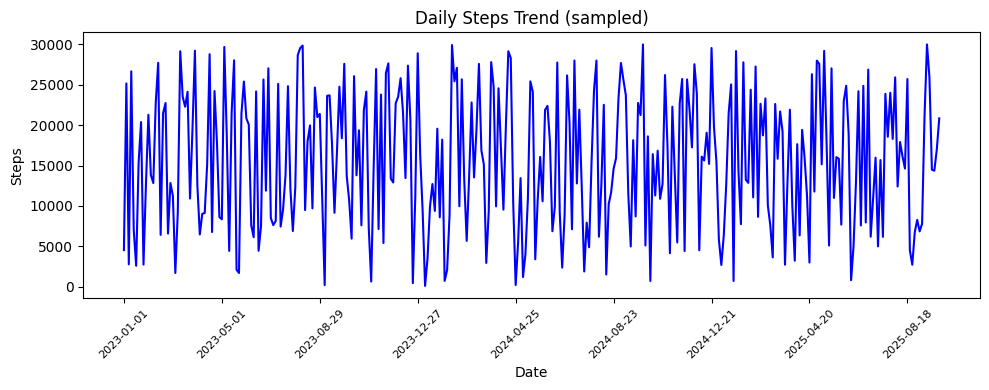

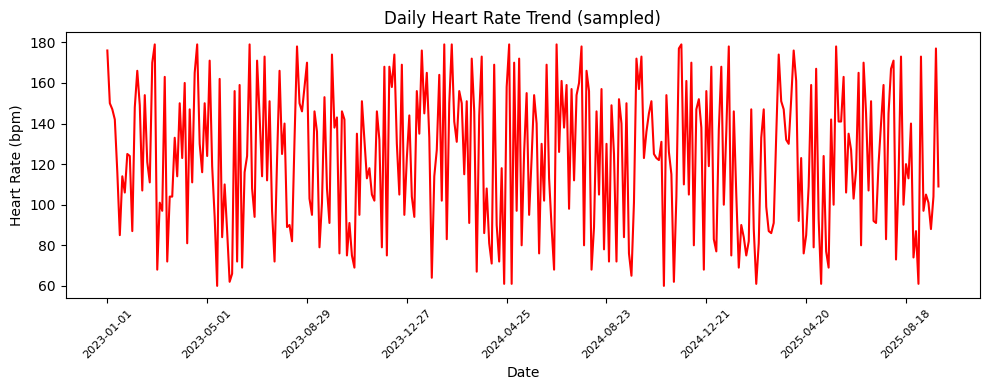

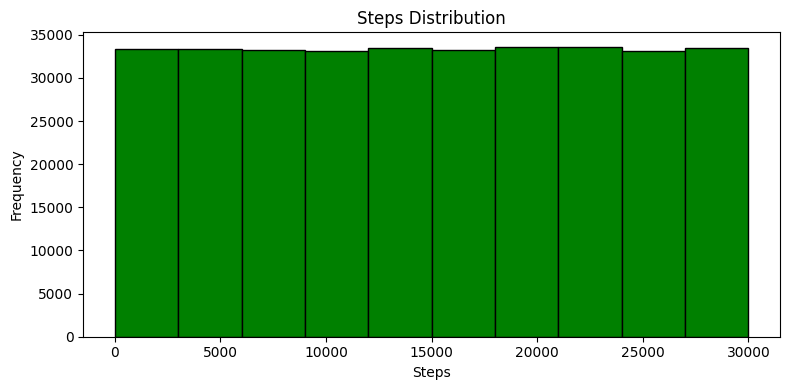


--- Visualizations for Miguel ---


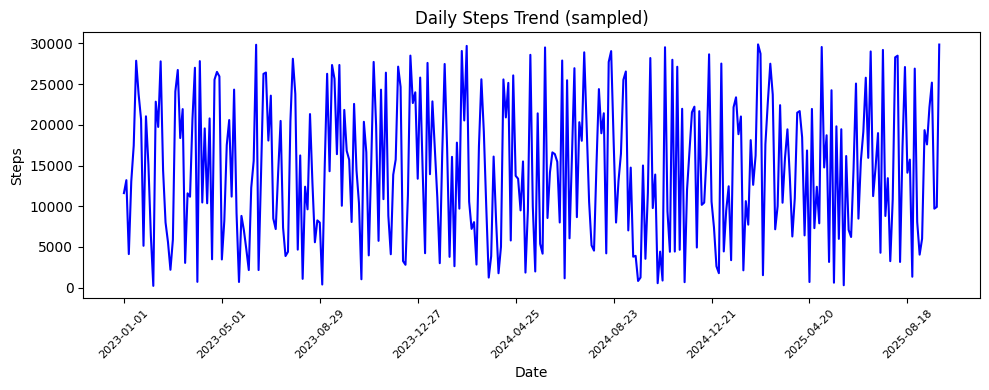

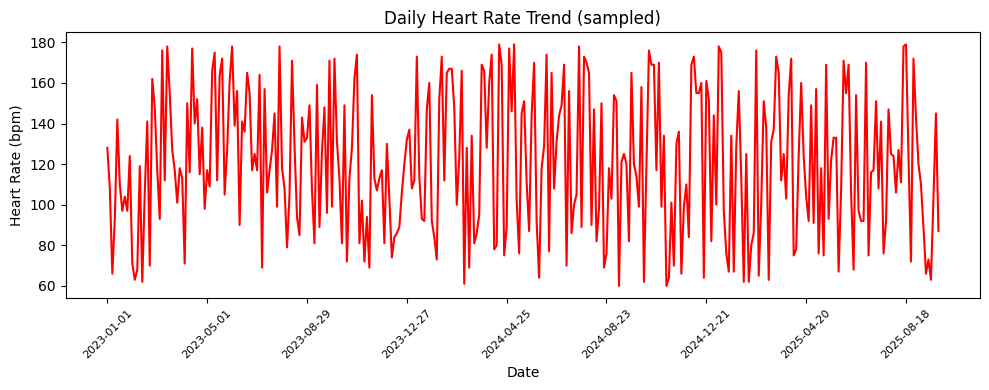

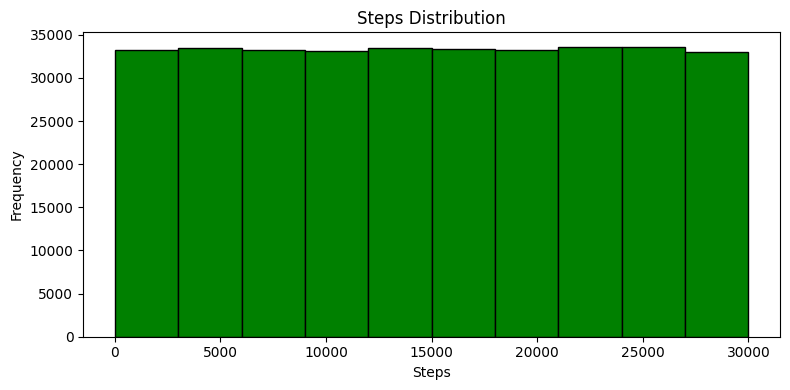


--- Visualizations for Ayush ---


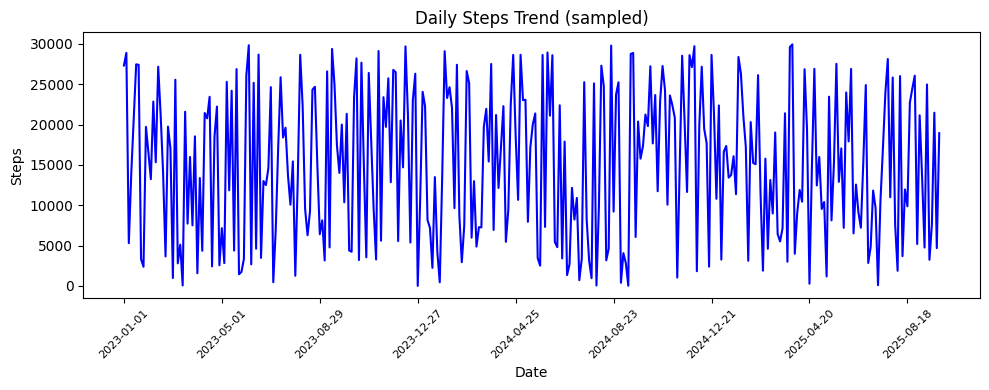

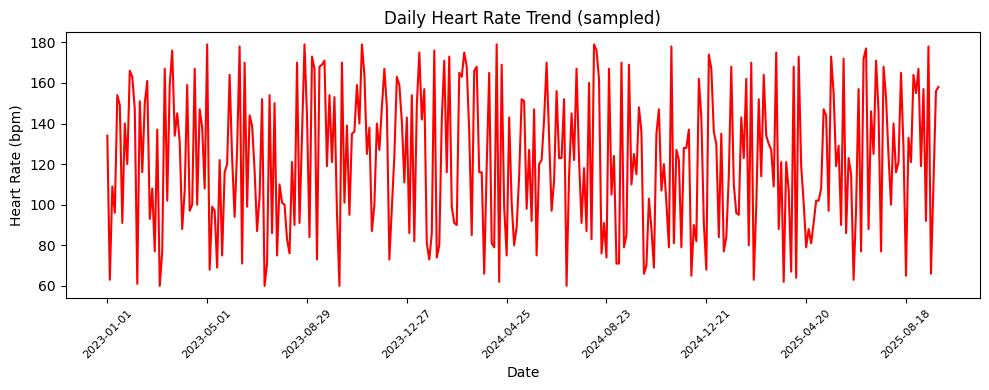

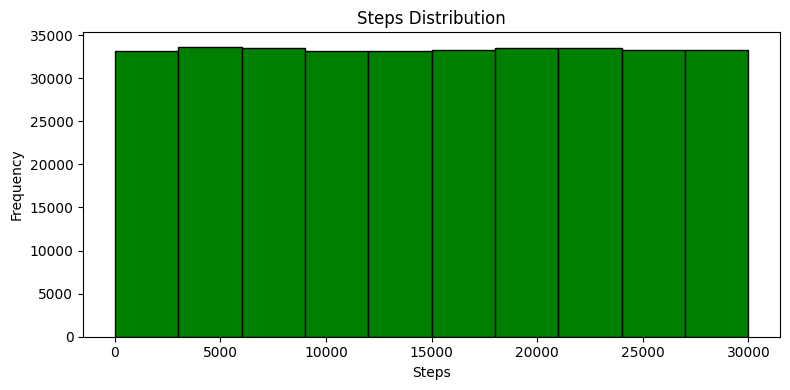

In [5]:
# visualizations for each profile
for p in profiles:
    print(f"\n--- Visualizations for {p.name} ---")
    plot_steps_trend(p.entries)
    plot_heart_rate_trend(p.entries)
    plot_steps_histogram(p.entries)

In [6]:
# Utility function demos for each profile
for p in profiles:
    print(f"\n--- Utility Function Demo for {p.name} ---")

    # Get step counts and convert to miles
    steps_list = get_step_counts(p.entries)
    miles = convert_steps_to_miles(steps_list)
    print("Miles walked (approx):", miles[:5], "...")

    # Filter days with high heart rate
    high_hr = filter_high_heart_rate(p.entries, threshold=100)
    print(f"Days with HR > 100: {len(high_hr)}")

    # Recursively sum steps for the first 5 days
    if len(p.entries) >= 5:
        total_steps_5 = recursive_sum_steps(p.entries, 4)
        # printing the total steps for the first 5 days
        print("Total steps (first 5 days):", total_steps_5)




--- Utility Function Demo for Shaun ---
Miles walked (approx): [2, 6, 0, 13, 7] ...
Days with HR > 100: 219135
Total steps (first 5 days): 60781

--- Utility Function Demo for Miguel ---
Miles walked (approx): [5, 7, 4, 5, 11] ...
Days with HR > 100: 218881
Total steps (first 5 days): 71264

--- Utility Function Demo for Ayush ---
Miles walked (approx): [13, 14, 4, 9, 9] ...
Days with HR > 100: 219362
Total steps (first 5 days): 104670


In [7]:
print("Analysis complete. Visualizations generated successfully.")

Analysis complete. Visualizations generated successfully.
